In [1]:
from environment import CoronagraphEnvironment
import hcipy
from hcipy import *
from matplotlib import pyplot as plt
import numpy as np


In [2]:
e = CoronagraphEnvironment(num_modes=5)

initializing coronagraph env. might take a minute.


In [3]:
def crop_image(img, width=40):
    if len(img.shape) == 1:
        img = img.reshape(int(np.sqrt(img.shape[0])), int(np.sqrt(img.shape[0])))

    center = (img.shape[0] // 2, img.shape[1] // 2)
    half_width = width // 2
    return img[center[0] - half_width: center[0] + half_width, center[1] - half_width: center[1] + half_width]


In [4]:
import torch

import torch.nn as nn
import torchvision.models as models

class LargeImageEncoderNet(nn.Module):
    def __init__(self, output_dim=10, input_shape=(40, 40)):
        super(LargeImageEncoderNet, self).__init__()
        h, w = input_shape
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(2304, 1024),
            nn.ReLU(),
            nn.Linear(1024, output_dim)
        )
        

    def forward(self, x):
        return self.encoder(x)

class SmallImageEncoderNet(nn.Module):
    def __init__(self, output_dim=10, input_shape=(40, 40)):
        super(SmallImageEncoderNet, self).__init__()

        height, width = input_shape

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten(),

            nn.Linear(32 * height * width, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    
    def forward(self, img):
        return self.encoder(img)

# Example usage:
model = LargeImageEncoderNet(output_dim=5)
output = model(torch.randn(1, 1, 40, 40))  # Example input

In [5]:
PATH = "models/CNN Large weights norm train extended.pth"

# Load the model's state_dict from the saved file
model.load_state_dict(torch.load(PATH))
model.eval()

LargeImageEncoderNet(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=2304, out_features=1024, bias=True)
    (14): ReLU()
    (15): Linear(in_features=1024, out_features=5, bias=True)
  )
)

cuda


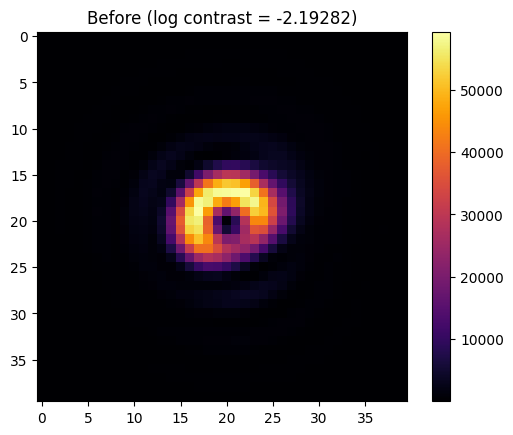

torch.Size([1, 1, 40, 40])


In [105]:
e.set_random_dm(noise=0.011)

plt.title(f'Before (log contrast = {round(np.log10(e.get_contrast()), 5)})')
image = (crop_image(np.clip(e.get_camera_image(delta_t=1), a_min = 1e-20, a_max = None) + 1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

image = np.array(image)

plt.imshow(image, cmap="inferno")
plt.colorbar()
plt.show()

image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
print(image_tensor.shape)

In [27]:
import pickle

with open('data/noise01/10000_samples_0.002_to_0.02_noise.pkl', 'rb') as f:
    data = pickle.load(f)

dm_settings = data["dm_settings"]
dm_std = np.std(dm_settings, axis=0)
dm_mean = np.mean(dm_settings, axis=0)

cuda


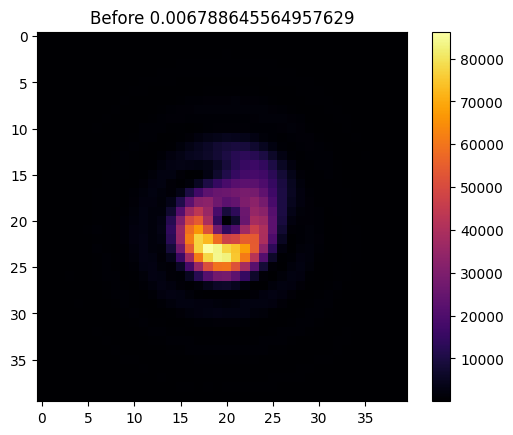

torch.Size([1, 1, 40, 40])
correction_prediction: tensor([[ 0.5261,  0.5344, -1.3589,  0.5224,  0.4173]])
correct answer: [ 3.65638812e-08  3.18568016e-08 -7.86582113e-08  3.11253659e-08
  2.18672143e-08]


C:\Users\alexe\AppData\Local\Temp\ipykernel_95380\1289031622.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)


cuda


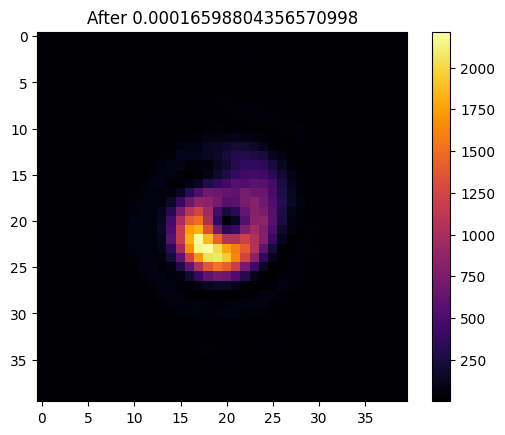

In [ ]:
#e.deformable_mirror.flatten()
#e.set_dm(-dm_settings[10])
# e.set_random_dm(0.011)

plt.title(f'Before {e.get_contrast(delta_t=10000)}')
image = (crop_image(np.clip(e.get_camera_image(delta_t=1), a_min = 1e-20, a_max = None) + 1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

image = np.array(image)

plt.imshow(image, cmap="inferno")
plt.colorbar()
plt.show()

image_tensor = torch.tensor(np.log(image), dtype=torch.float32).unsqueeze(0).unsqueeze(0)
print(image_tensor.shape)


#manual_test_torch = torch.tensor(image.transpose(0, 3, 1, 2), dtype=torch.float32)
#manual_test_torch = F.interpolate(manual_test_torch, size=(224, 224), mode='bilinear', align_corners=False)
#manual_test_torch = manual_test_torch.to(device)
with torch.no_grad():
    y_pred = model(image_tensor)
    print(f"correction_prediction: {y_pred}")
    print(f"correct answer: {-e.deformable_mirror.actuators}")

e.set_dm(np.array(y_pred[0].to('cpu')) * dm_std + dm_mean)

plt.title(f'After {e.get_contrast(delta_t=10000)}')

image = (crop_image(np.clip(e.get_camera_image(delta_t=1), a_min = 1e-20, a_max = None) + 1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

image = np.array(image)

plt.imshow(image, cmap="inferno")
plt.colorbar()
plt.show()